In [13]:
import pickle
import json
import ast

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
gdata = pd.read_csv("TxG_Data_ML_v1.csv")

In [3]:
gdata.head()

,graph6,AdjMat,order,delta,Delta,kappa,mr_lower,mr_upper,Z
0,D}g,"[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",5,2,4,2,3,3,2
1,Kw?{o?HOOa?F,"[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",12,3,3,3,7,8,5
2,J[`A?_G@?C?,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, ...",11,1,3,1,8,8,3
3,H[`A?_G,"[0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, ...",9,1,3,1,6,6,3
4,I`r@`_I@W,"[1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...",10,3,3,2,6,6,4


In [4]:
gdata['AdjMat'] = gdata['AdjMat'].apply(json.loads)

In [5]:
type(gdata['AdjMat'].iloc[0])

list

In [6]:
gdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   graph6    159 non-null    object
 1   AdjMat    159 non-null    object
 2   order     159 non-null    int64 
 3   delta     159 non-null    int64 
 4   Delta     159 non-null    int64 
 5   kappa     159 non-null    int64 
 6   mr_lower  159 non-null    int64 
 7   mr_upper  159 non-null    int64 
 8   Z         159 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 11.3+ KB


## Turns edges into categorical data

In [7]:
expanded = pd.DataFrame(gdata['AdjMat'].tolist())

In [8]:
expanded.columns = [f"edge_{i}" for i in range(expanded.shape[1])]

In [9]:
expanded.head()

,edge_0,edge_1,edge_2,edge_3,edge_4,edge_5,edge_6,edge_7,edge_8,edge_9,...,edge_266,edge_267,edge_268,edge_269,edge_270,edge_271,edge_272,edge_273,edge_274,edge_275
0,1,1,1,1,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
gdata = pd.concat([gdata, expanded], axis=1)

In [12]:
gdata.head()

,graph6,AdjMat,order,delta,Delta,kappa,mr_lower,mr_upper,Z,edge_0,...,edge_266,edge_267,edge_268,edge_269,edge_270,edge_271,edge_272,edge_273,edge_274,edge_275
0,D}g,"[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",5,2,4,2,3,3,2,1,...,0,0,0,0,0,0,0,0,0,0
1,Kw?{o?HOOa?F,"[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",12,3,3,3,7,8,5,1,...,0,0,0,0,0,0,0,0,0,0
2,J[`A?_G@?C?,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, ...",11,1,3,1,8,8,3,0,...,0,0,0,0,0,0,0,0,0,0
3,H[`A?_G,"[0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, ...",9,1,3,1,6,6,3,0,...,0,0,0,0,0,0,0,0,0,0
4,I`r@`_I@W,"[1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...",10,3,3,2,6,6,4,1,...,0,0,0,0,0,0,0,0,0,0


## Add features

### Edge connectivity

In [17]:
gdata["lambda"] = gdata["graph6"].apply(
    lambda x: nx.edge_connectivity(
                nx.from_graph6_bytes(x.encode())
    )
)

In [19]:
col = gdata.pop("lambda")
gdata.insert(6, "lambda", col)

### Maximum nullity

In [28]:
gdata["mr"] = np.where(
    gdata["mr_lower"]==gdata["mr_upper"],
    gdata["mr_lower"],
    np.nan
)

In [26]:
col = gdata.pop("mr")
gdata.insert(7, "mr", col)

In [30]:
gdata["M"] = gdata["order"] - gdata["mr"]

In [32]:
col = gdata.pop("M")
gdata.insert(7, "M", col)

### Z(G) - M(G)

In [34]:
gdata["ZM_diff"] = gdata["Z"] - gdata["M"]

In [35]:
col = gdata.pop("ZM_diff")
gdata.insert(7, "ZM_diff", col)

### Check data

In [36]:
gdata.head()

,graph6,AdjMat,order,delta,Delta,kappa,lambda,ZM_diff,M,mr,...,edge_266,edge_267,edge_268,edge_269,edge_270,edge_271,edge_272,edge_273,edge_274,edge_275
0,D}g,"[1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",5,2,4,2,2,0.0,2.0,3.0,...,0,0,0,0,0,0,0,0,0,0
1,Kw?{o?HOOa?F,"[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",12,3,3,3,3,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,J[`A?_G@?C?,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, ...",11,1,3,1,1,0.0,3.0,8.0,...,0,0,0,0,0,0,0,0,0,0
3,H[`A?_G,"[0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, ...",9,1,3,1,1,0.0,3.0,6.0,...,0,0,0,0,0,0,0,0,0,0
4,I`r@`_I@W,"[1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...",10,3,3,2,2,0.0,4.0,6.0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
(gdata["ZM_diff"]>0).sum()

np.int64(3)

In [40]:
gdata.shape

(159, 289)

## Split data

In [13]:
X = gdata.drop(columns = ['graph6', 'AdjMat', 'mr_lower', 'mr_upper'])
y = gdata['mr_lower']

In [14]:
X.head()

,order,delta,Delta,kappa,Z,edge_0,edge_1,edge_2,edge_3,edge_4,...,edge_266,edge_267,edge_268,edge_269,edge_270,edge_271,edge_272,edge_273,edge_274,edge_275
0,5,2,4,2,2,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,12,3,3,3,5,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,11,1,3,1,3,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,9,1,3,1,3,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,10,3,3,2,4,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


# XGBoost examples

In [29]:
X_train, X_tv, y_train, y_tv = train_test_split(
    X,y, test_size=0.4, 
    # random_state=41
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tv, y_tv, test_size=0.5, 
    # random_state=41
)

In [32]:
vals_mse = []
vals_r2 = []
tests_mse = []
tests_r2 = []

n_estimators_list = [(i+1)*50 for i in range(5)]

for i in range(5):

    n_est = n_estimators_list[i]

    print(f"n_estimators = {n_est}")

    model = XGBRegressor(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=41,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    # ---- Validation ----
    val_preds = model.predict(X_val)
    val_mse = mean_squared_error(y_val, val_preds)
    val_r2 = r2_score(y_val, val_preds)

    print("Val MSE:", val_mse)
    print("Val R2:", val_r2)

    vals_mse.append(val_mse)
    vals_r2.append(val_r2)

    # ---- Test ----
    test_preds = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)

    print("Test MSE:", test_mse)
    print("Test R2:", test_r2)

    tests_mse.append(test_mse)
    tests_r2.append(test_r2)

    # ---- Feature importance ----
    importances = pd.Series(model.feature_importances_, index=X.columns)
    print(importances.sort_values(ascending=False).head(3))
    print()

n_estimators = 50
Val MSE: 0.9560169577598572
Val R2: 0.8614938855171204
Test MSE: 0.6548982858657837
Test R2: 0.8857942819595337
edge_37    0.252175
edge_23    0.197328
edge_76    0.122289
dtype: float32

n_estimators = 100
Val MSE: 0.9087491035461426
Val R2: 0.8683419227600098
Test MSE: 0.5874626636505127
Test R2: 0.8975542187690735
edge_37    0.351074
edge_23    0.206042
edge_76    0.086495
dtype: float32

n_estimators = 150
Val MSE: 0.9229032397270203
Val R2: 0.866291344165802
Test MSE: 0.5760935544967651
Test R2: 0.8995368480682373
edge_37    0.288646
edge_23    0.169406
edge_76    0.142227
dtype: float32

n_estimators = 200
Val MSE: 0.921920120716095
Val R2: 0.8664337396621704
Test MSE: 0.5718774199485779
Test R2: 0.9002720713615417
edge_23    0.196200
edge_37    0.167150
edge_76    0.123542
dtype: float32

n_estimators = 250
Val MSE: 0.9221025705337524
Val R2: 0.8664073348045349
Test MSE: 0.5706487894058228
Test R2: 0.9004862904548645
edge_23    0.181451
edge_37    0.165626
edge

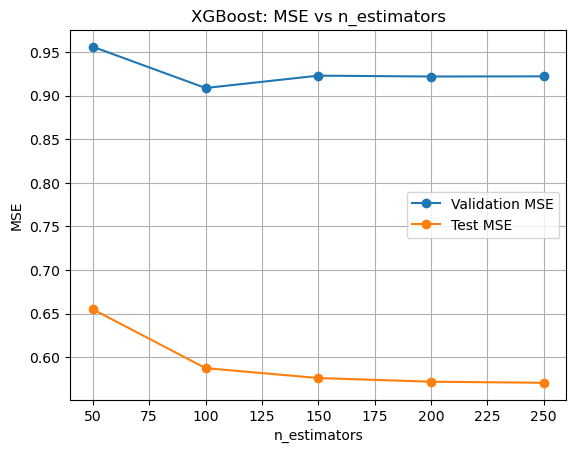

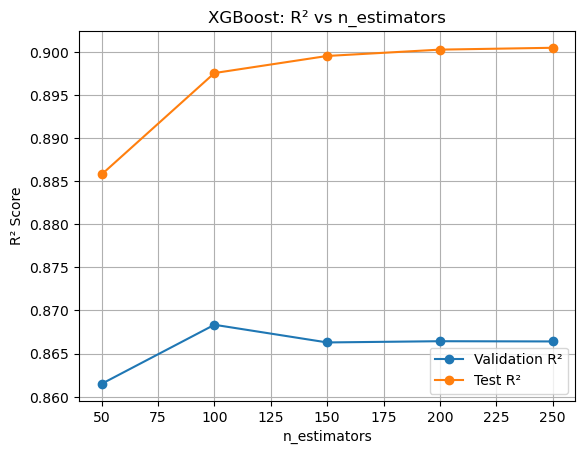

In [33]:
n_estimators = [(i+1)*50 for i in range(5)]

# ---- MSE plot ----
plt.figure()
plt.plot(n_estimators, vals_mse, marker='o', label='Validation MSE')
plt.plot(n_estimators, tests_mse, marker='o', label='Test MSE')
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.title("XGBoost: MSE vs n_estimators")
plt.legend()
plt.grid(True)
plt.show()

# ---- R² plot ----
plt.figure()
plt.plot(n_estimators, vals_r2, marker='o', label='Validation R²')
plt.plot(n_estimators, tests_r2, marker='o', label='Test R²')
plt.xlabel("n_estimators")
plt.ylabel("R² Score")
plt.title("XGBoost: R² vs n_estimators")
plt.legend()
plt.grid(True)
plt.show()

# Random forest examples

In [16]:
X_train, X_tv, y_train, y_tv = train_test_split(
    X,y, test_size=0.4, random_state=41
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tv, y_tv, test_size=0.5, random_state=41
)

In [27]:
vals_mse = []
vals_r2 = []
tests_mse = []
tests_r2 = []

for i in range(5):
    
    b_est = 50
    n_est = (i+1)*50

    print(f"n_estimators = {n_est}")

    model = RandomForestRegressor(
        n_estimators = n_est,
        # random_state=41,
        n_jobs=-1
    )
    model.fit(X_train,y_train)

    val_preds = model.predict(X_val)
    val_mse = mean_squared_error(y_val, val_preds)
    val_r2 = r2_score(y_val, val_preds)
    print("Val MSE:", val_mse)
    print("Val R2:", val_r2)
    vals_mse.append(val_mse)
    vals_r2.append(val_r2)

    test_preds = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_preds)
    test_r2 = r2_score(y_test, test_preds)
    print("Test MSE:", test_mse)
    print("Test R2:", test_r2)
    tests_mse.append(test_mse)
    tests_r2.append(test_r2)

    importances = pd.Series(model.feature_importances_, index=X.columns)
    print(importances.sort_values(ascending=False).head(3))
    print()

n_estimators = 50
Val MSE: 3.812925
Val R2: 0.6853038446038526
Test MSE: 0.9283499999999999
Test R2: 0.8596855498154982
order    0.721930
Z        0.067046
Delta    0.053073
dtype: float64

n_estimators = 100
Val MSE: 3.82799375
Val R2: 0.6840601595873297
Test MSE: 0.8286375000000004
Test R2: 0.8747564870848707
order    0.756583
Z        0.073559
Delta    0.039429
dtype: float64

n_estimators = 150
Val MSE: 3.9921041666666666
Val R2: 0.6705154617017275
Test MSE: 0.9480875000000002
Test R2: 0.8567023468634686
order    0.732884
Z        0.063334
Delta    0.052900
dtype: float64

n_estimators = 200
Val MSE: 3.5717203125
Val R2: 0.7052114451519303
Test MSE: 0.9798312499999999
Test R2: 0.8519044723247232
order    0.740675
Z        0.065200
Delta    0.049449
dtype: float64

n_estimators = 250
Val MSE: 4.0450800000000005
Val R2: 0.666143151446764
Test MSE: 0.9478424999999998
Test R2: 0.8567393771217713
order    0.733992
Z        0.066632
Delta    0.052635
dtype: float64



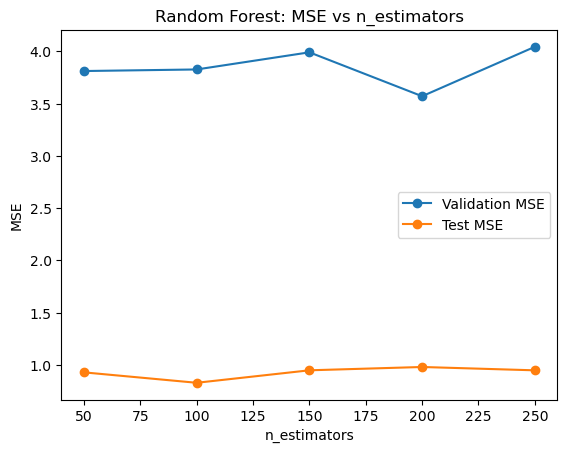

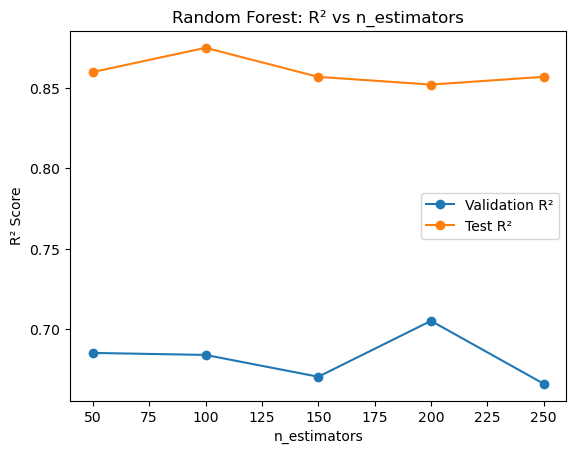

In [31]:
n_estimators = [(i+1)*50 for i in range(5)]

# ---- MSE plot ----
plt.figure()
plt.plot(n_estimators, vals_mse, marker='o', label='Validation MSE')
plt.plot(n_estimators, tests_mse, marker='o', label='Test MSE')
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.title("Random Forest: MSE vs n_estimators")
plt.legend()
plt.grid(False)
plt.show()

# ---- R² plot ----
plt.figure()
plt.plot(n_estimators, vals_r2, marker='o', label='Validation R²')
plt.plot(n_estimators, tests_r2, marker='o', label='Test R²')
plt.xlabel("n_estimators")
plt.ylabel("R² Score")
plt.title("Random Forest: R² vs n_estimators")
plt.legend()
plt.grid(False)
plt.show()

In [17]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=41,
    n_jobs=-1
)

In [18]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
val_preds = model.predict(X_val)

print("Val MSE:", mean_squared_error(y_val, val_preds))
print("Val R2:", r2_score(y_val, val_preds))

Val MSE: 4.053846875
Val R2: 0.6654195857177401


In [21]:
test_preds = model.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, test_preds))
print("Test R2:", r2_score(y_test, test_preds))

Test MSE: 0.953246875
Test R2: 0.8559225387453875


In [22]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(20))

order       0.747443
Z           0.060327
Delta       0.050332
edge_10     0.014268
edge_108    0.010133
edge_107    0.009754
edge_99     0.009656
edge_88     0.006921
edge_78     0.006156
edge_66     0.006008
delta       0.005583
edge_0      0.004824
edge_98     0.003947
edge_6      0.003621
edge_14     0.003482
edge_89     0.003132
edge_7      0.003086
edge_9      0.003081
edge_4      0.002952
kappa       0.002929
dtype: float64
